# Salads Sub-Department — Deep Dive Analysis (2026 YTD)
**Period:** 1 January – 23 April 2026 · **92 trading days**

**Data sources:**
- `foodland_data.db` — `fact_sales` (POS, Salads sub_dept, 52 items)
- Dump Stock Report (3).xlsx — weekly transaction-level write-offs
- Markdown Report.xlsx — period-aggregate discounted sales

**Sections:**
1. Setup & data loading
2. Salads sales overview
3. Weekly sales & waste trends
4. Item portfolio analysis
5. Dump waste deep dive
6. Markdown deep dive
7. Combined waste picture per item
8. Recommendations


## 1. Setup & Data Loading

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from pathlib import Path
import os
import re
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
})

# ── Paths ─────────────────────────────────────────────────────────────────────
_nb_dir = Path(os.path.abspath(''))
PROJECT_ROOT = _nb_dir.parent if _nb_dir.name == '02_analysis' else _nb_dir
DB_PATH    = PROJECT_ROOT / 'foodland_data.db'
DUMP_PATH  = PROJECT_ROOT / '01_data' / 'raw' / 'Dump' / 'Dump Stock Report (3).xlsx'
MD_PATH    = PROJECT_ROOT / '01_data' / 'raw' / 'Markdown' / 'Markdown Report.xlsx'
CHARTS_DIR = PROJECT_ROOT / '02_analysis' / 'charts'
CHARTS_DIR.mkdir(exist_ok=True)

PERIOD_START  = '2026-01-01'
PERIOD_END    = '2026-04-23'
TRADING_DAYS  = 92
PERIOD_WEEKS  = 17   # Jan 1 → Apr 23 ≈ 17 full weeks

print(f"Project root : {PROJECT_ROOT}")
print(f"DB exists    : {DB_PATH.exists()}")


Project root : c:\Users\fabio\OneDrive\Documentos\foodland_wudinna
DB exists    : True


In [2]:
# ── Helper: normalise description strings for cross-source matching ───────────
def norm(s):
    """Uppercase, collapse whitespace, strip."""
    if pd.isna(s): return ''
    return re.sub(r'\s+', ' ', str(s).upper().strip())


In [3]:
# ── Load POS sales — Salads sub_dept ─────────────────────────────────────────
con = sqlite3.connect(f'file:{DB_PATH}?immutable=1', uri=True)

sales = pd.read_sql(f"""
    SELECT fs.date_id AS date,
           dd.day_name, dd.day_of_week, dd.month, dd.month_name,
           dd.week_num, dd.year,
           dp.name,
           fs.sales_ex_gst, fs.gp_dollars, fs.gp_pct,
           fs.quantity, fs.lines
    FROM fact_sales fs
    JOIN dim_product dp ON fs.product_id = dp.product_id
    JOIN dim_date    dd ON fs.date_id    = dd.date_id
    WHERE dp.sub_dept = 'Salads'
      AND fs.date_id >= '{PERIOD_START}'
      AND fs.date_id <= '{PERIOD_END}'
""", con)

# All salads items registered in the POS
salad_items_df = pd.read_sql(
    "SELECT name FROM dim_product WHERE sub_dept = 'Salads'", con)
con.close()

sales['date'] = pd.to_datetime(sales['date'])
sales['week']  = sales['date'].dt.to_period('W')
sales['month_label'] = sales['month_name'].str[:3]
salad_names_norm = set(salad_items_df['name'].apply(norm))

print(f"Sales rows: {len(sales):,} | Items: {sales['name'].nunique()} | Days: {sales['date'].nunique()}")


Sales rows: 1,356 | Items: 52 | Days: 90


In [4]:
# ── Load Dump Stock — tag departments, filter to FV ───────────────────────────
dump_raw = pd.read_excel(DUMP_PATH, sheet_name='Page 1', header=4)
dump_raw = dump_raw.dropna(axis=1, how='all')

current_dept = None; dept_col = []
for _, row in dump_raw.iterrows():
    val = str(row['Store']).strip() if pd.notna(row['Store']) else ''
    if val in {'DAIRY','FRUIT & VEG','MEAT'}:
        current_dept = val; dept_col.append(None)
    else:
        dept_col.append(current_dept)
dump_raw['Department'] = dept_col
dump_fv = dump_raw[(dump_raw['Store'] == 'Foodland Wudinna') &
                    (dump_raw['Department'] == 'FRUIT & VEG')].copy()
dump_fv['Date'] = pd.to_datetime(dump_fv['Date'], dayfirst=True, errors='coerce')
for col in ['Qty','Unit Cost ex','Total Cost ex','Total Sell ex']:
    dump_fv[col] = pd.to_numeric(dump_fv[col], errors='coerce')
dump_fv['week']      = dump_fv['Date'].dt.to_period('W')
dump_fv['month']     = dump_fv['Date'].dt.to_period('M')
dump_fv['desc_norm'] = dump_fv['Description'].apply(norm)

# Flag salad vs non-salad dump lines
dump_fv['is_salad'] = dump_fv['desc_norm'].isin(salad_names_norm)
dump_salads = dump_fv[dump_fv['is_salad']].copy()
dump_other  = dump_fv[~dump_fv['is_salad']].copy()

print(f"FV dump rows: {len(dump_fv)} total | {len(dump_salads)} salads | {len(dump_other)} other FV")
print(f"Date range: {dump_fv['Date'].min().date()} → {dump_fv['Date'].max().date()}")


FV dump rows: 158 total | 68 salads | 90 other FV
Date range: 2026-01-06 → 2026-04-23


In [5]:
# ── Load Markdown — filter to FV, flag salads ────────────────────────────────
md_raw = pd.read_excel(MD_PATH, sheet_name='Page 1', header=None)
SKIP = {' ezi-manager CLOUD','Group Total','Result Total','Foodland Wudinna',
        'Filter: Is in Departments DAIRY, MEAT, FRUIT & VEG','APN'}

current_dept = None; records = []; col_headers = None
for _, row in md_raw.iterrows():
    val0 = str(row.iloc[0]).strip() if pd.notna(row.iloc[0]) else ''
    if val0 == 'APN':
        col_headers = [str(v).strip() if pd.notna(v) else '' for v in row.tolist()]; continue
    if val0 in {'DAIRY','FRUIT & VEG','MEAT'}: current_dept = val0; continue
    if val0 in SKIP or val0 == '' or pd.isna(row.iloc[0]): continue
    try: int(float(str(val0).replace('.0','')))
    except: continue
    if current_dept and col_headers:
        rec = {'Department': current_dept}
        for ci, cv in zip(col_headers, row.tolist()):
            if ci: rec[ci] = cv
        records.append(rec)

markdowns = pd.DataFrame(records)
markdowns = markdowns[[c for c in markdowns.columns if c and not c.startswith('Unnamed') and c != '']]
for col in ['Qty','Potential Sell','Total Sell','Total Cost','Discount Given','Realised Profit','GP']:
    if col in markdowns.columns:
        markdowns[col] = pd.to_numeric(markdowns[col], errors='coerce')

md_fv = markdowns[markdowns['Department'] == 'FRUIT & VEG'].copy()
md_fv['desc_norm'] = md_fv['Description'].apply(norm)
md_fv['is_salad']  = md_fv['desc_norm'].isin(salad_names_norm)
md_salads = md_fv[md_fv['is_salad']].copy()
md_other  = md_fv[~md_fv['is_salad']].copy()

print(f"FV markdown rows: {len(md_fv)} total | {len(md_salads)} salads | {len(md_other)} other FV")


FV markdown rows: 75 total | 37 salads | 38 other FV


## 2. Salads Sales Overview

In [6]:
# ── Key metrics ──────────────────────────────────────────────────────────────
total_rev   = sales['sales_ex_gst'].sum()
total_gp    = sales['gp_dollars'].sum()
gp_pct      = total_gp / total_rev * 100
rev_per_day = total_rev / TRADING_DAYS
rev_per_week= total_rev / PERIOD_WEEKS
active_items = sales['name'].nunique()
total_qty   = sales['quantity'].sum()

print("=" * 55)
print(f"  Total revenue (ex GST)    : ${total_rev:>10,.2f}")
print(f"  Revenue / trading day     : ${rev_per_day:>10,.2f}")
print(f"  Revenue / week            : ${rev_per_week:>10,.2f}")
print(f"  Total GP                  : ${total_gp:>10,.2f}")
print(f"  GP%                       : {gp_pct:>10.1f}%")
print(f"  Units sold                : {total_qty:>10,.0f}")
print(f"  Active items (in POS)     : {active_items:>10}")
print(f"  Registered items (total)  : {len(salad_items_df):>10}")
print("=" * 55)


  Total revenue (ex GST)    : $ 18,744.51
  Revenue / trading day     : $    203.74
  Revenue / week            : $  1,102.62
  Total GP                  : $  6,022.65
  GP%                       :       32.1%
  Units sold                :      3,996
  Active items (in POS)     :         52
  Registered items (total)  :         52


Monthly Salads breakdown:
month_label     rev  gp_pct     qty  days  rev_per_day
        Jan 5329.23   31.53 1142.46    25       213.17
        Feb 5105.66   32.20 1090.09    24       212.74
        Mar 4866.50   31.59 1048.61    25       194.66
        Apr 3443.12   33.73  714.42    16       215.20


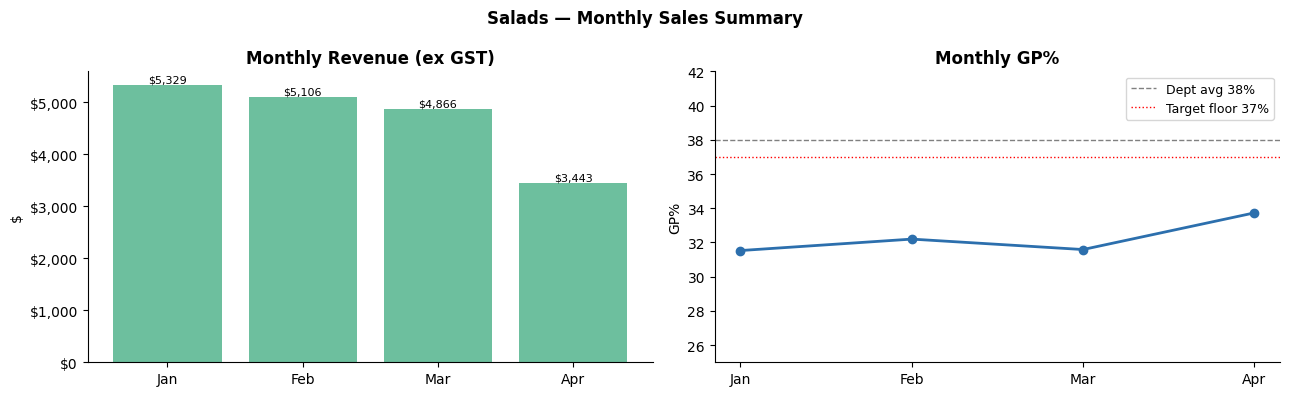

In [7]:
# ── Monthly breakdown ─────────────────────────────────────────────────────────
monthly = (sales.groupby(['month','month_name'])
           .agg(rev=('sales_ex_gst','sum'), gp=('gp_dollars','sum'),
                qty=('quantity','sum'), days=('date','nunique'))
           .reset_index())
monthly['gp_pct']    = monthly['gp'] / monthly['rev'] * 100
monthly['rev_per_day']= monthly['rev'] / monthly['days']
monthly['month_label']= monthly['month_name'].str[:3]

print("Monthly Salads breakdown:")
print(monthly[['month_label','rev','gp_pct','qty','days','rev_per_day']].round(2).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(monthly['month_label'], monthly['rev'], color='#6dbf9e')
axes[0].set_title('Monthly Revenue (ex GST)')
axes[0].set_ylabel('$')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, (_, row) in enumerate(monthly.iterrows()):
    axes[0].text(i, row['rev'] + 50, f"${row['rev']:,.0f}", ha='center', fontsize=8)

axes[1].plot(monthly['month_label'], monthly['gp_pct'], color='#2c6fad', marker='o', linewidth=2)
axes[1].axhline(38.0, color='grey', linestyle='--', linewidth=1, label='Dept avg 38%')
axes[1].axhline(37.0, color='red', linestyle=':', linewidth=1, label='Target floor 37%')
axes[1].set_title('Monthly GP%')
axes[1].set_ylabel('GP%')
axes[1].set_ylim(25, 42)
axes[1].legend(fontsize=9)

plt.suptitle('Salads — Monthly Sales Summary', fontweight='bold')
plt.tight_layout()
plt.savefig(str(CHARTS_DIR / 'salads_monthly_sales.png'), dpi=150, bbox_inches='tight')
plt.show()


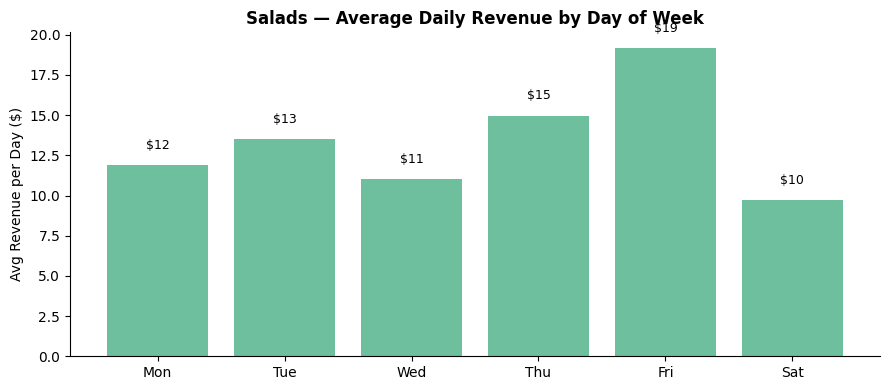


Friday index vs weekday avg: 1.49x


In [8]:
# ── Day-of-week pattern ───────────────────────────────────────────────────────
dow = (sales.groupby(['day_of_week','day_name'])['sales_ex_gst'].mean().reset_index()
       .sort_values('day_of_week'))
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(dow_labels, dow['sales_ex_gst'], color='#6dbf9e')
ax.set_ylabel('Avg Revenue per Day ($)')
ax.set_title('Salads — Average Daily Revenue by Day of Week')
for bar, val in zip(bars, dow['sales_ex_gst']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'${val:.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(str(CHARTS_DIR / 'salads_dow.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nFriday index vs weekday avg:",
      f"{dow[dow['day_name']=='Friday']['sales_ex_gst'].values[0] / dow[dow['day_name'].isin(['Monday','Tuesday','Wednesday','Thursday'])]['sales_ex_gst'].mean():.2f}x")


## 3. Weekly Sales & Waste Trends

In [9]:
# ── Weekly sales ─────────────────────────────────────────────────────────────
weekly_sales = (sales.groupby('week')
                .agg(rev=('sales_ex_gst','sum'), gp=('gp_dollars','sum'),
                     qty=('quantity','sum'), days=('date','nunique'))
                .reset_index())
weekly_sales['gp_pct'] = weekly_sales['gp'] / weekly_sales['rev'] * 100
weekly_sales['week_str'] = weekly_sales['week'].astype(str).str[5:10]  # MM/DD

# ── Weekly dump cost (salads only) ────────────────────────────────────────────
weekly_dump = (dump_salads.groupby('week')
               .agg(dump_cost=('Total Cost ex','sum'), dump_qty=('Qty','sum'),
                    dump_lines=('Qty','count'))
               .reset_index())

# ── Merge sales + dump ────────────────────────────────────────────────────────
weekly = pd.merge(weekly_sales, weekly_dump, on='week', how='left').fillna(0)
weekly['dump_pct_rev'] = weekly['dump_cost'] / weekly['rev'] * 100
weekly['week_label']   = weekly['week'].astype(str).str[5:10]

print(f"Weeks with dump activity: {(weekly['dump_cost'] > 0).sum()} of {len(weekly)}")
print(f"\nWeekly summary:")
print(weekly[['week_label','rev','gp_pct','dump_cost','dump_qty','dump_pct_rev']].round(2).to_string(index=False))


Weeks with dump activity: 14 of 17

Weekly summary:
week_label     rev  gp_pct  dump_cost  dump_qty  dump_pct_rev
     12-29  214.70   24.07       0.00       0.0          0.00
     01-05 1114.27   30.16       0.00       0.0          0.00
     01-12 1202.09   31.87      24.63       9.0          2.05
     01-19 1547.64   31.29       0.00       0.0          0.00
     01-26 1250.54   34.00      15.30       3.0          1.22
     02-02 1402.57   32.87       5.26       1.0          0.37
     02-09 1263.97   29.16      10.16       3.0          0.80
     02-16 1259.46   33.74      48.58       9.0          3.86
     02-23 1179.66   33.00       5.10       1.0          0.43
     03-02  941.56   30.19     279.98      59.0         29.74
     03-09 1060.04   28.08      98.39      17.0          9.28
     03-16 1083.00   33.19      11.76       2.0          1.09
     03-23 1267.39   32.88      52.53      14.0          4.14
     03-30 1467.26   36.79      52.86      11.0          3.60
     04-06  867.92

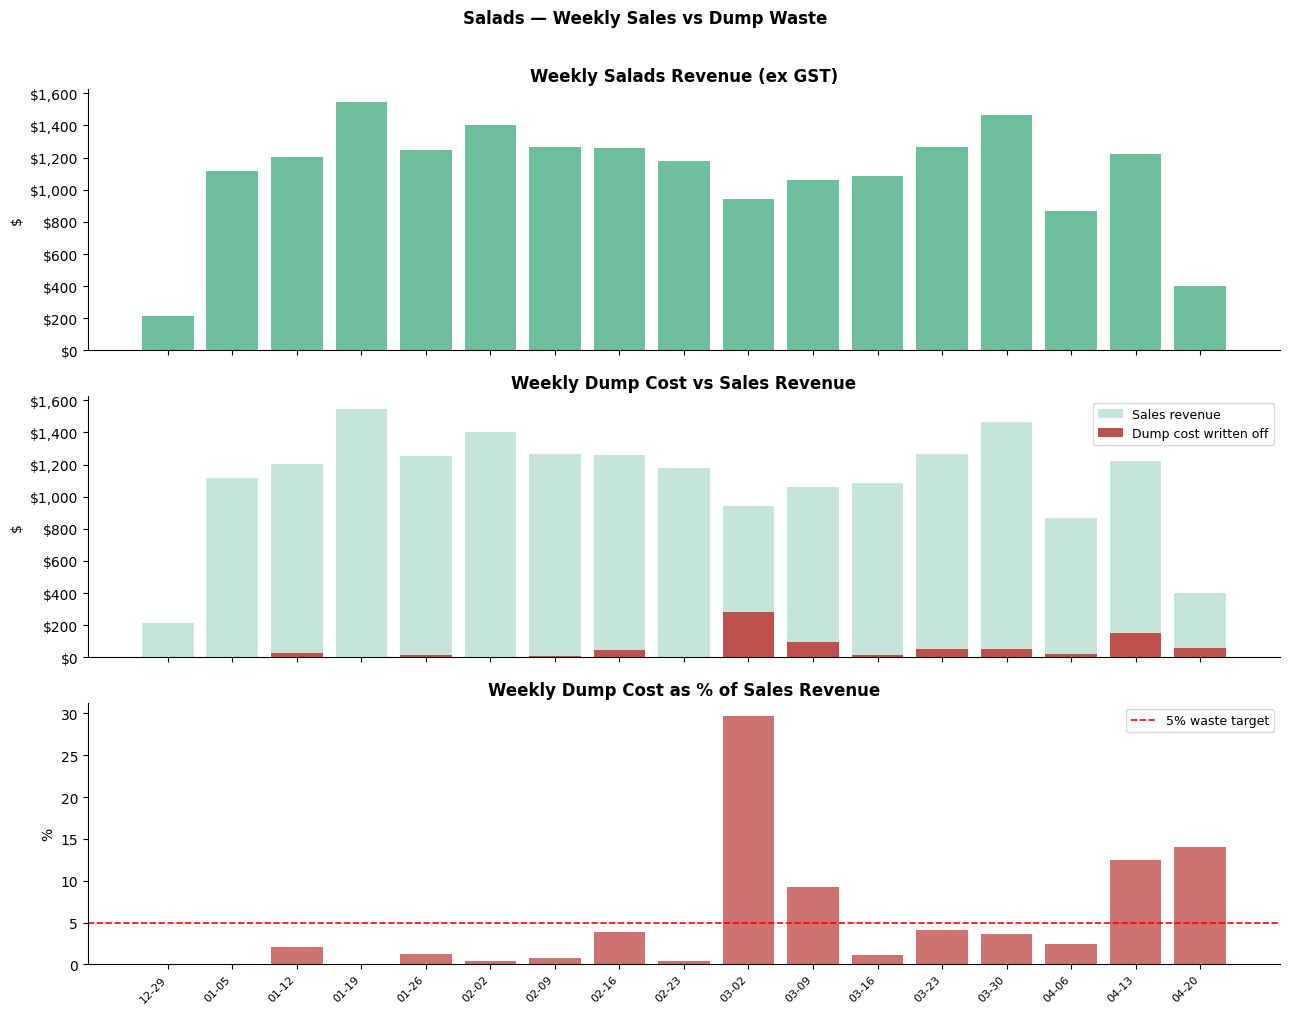

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

x  = range(len(weekly))
wl = weekly['week_label'].tolist()

# Revenue
axes[0].bar(x, weekly['rev'], color='#6dbf9e', label='Sales revenue')
axes[0].set_title('Weekly Salads Revenue (ex GST)')
axes[0].set_ylabel('$')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))

# Dump cost overlaid on sales
axes[1].bar(x, weekly['rev'], color='#6dbf9e', alpha=0.4, label='Sales revenue')
axes[1].bar(x, weekly['dump_cost'], color='#c0504d', label='Dump cost written off')
axes[1].set_title('Weekly Dump Cost vs Sales Revenue')
axes[1].set_ylabel('$')
axes[1].legend(fontsize=9)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))

# Dump as % of sales
axes[2].bar(x, weekly['dump_pct_rev'], color='#c0504d', alpha=0.8)
axes[2].axhline(5, color='red', linestyle='--', linewidth=1.2, label='5% waste target')
axes[2].set_title('Weekly Dump Cost as % of Sales Revenue')
axes[2].set_ylabel('%')
axes[2].legend(fontsize=9)

axes[2].set_xticks(list(x))
axes[2].set_xticklabels(wl, rotation=45, ha='right', fontsize=8)
plt.suptitle('Salads — Weekly Sales vs Dump Waste', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(str(CHARTS_DIR / 'salads_weekly_sales_dump.png'), dpi=150, bbox_inches='tight')
plt.show()


In [11]:
# ── Waste summary stats ───────────────────────────────────────────────────────
total_dump_cost = weekly['dump_cost'].sum()
total_dump_qty  = weekly['dump_qty'].sum()
peak_week       = weekly.loc[weekly['dump_cost'].idxmax(), 'week_label']
peak_cost       = weekly['dump_cost'].max()
avg_dump_week   = weekly[weekly['dump_cost'] > 0]['dump_cost'].mean()
dump_pct_total  = total_dump_cost / total_rev * 100

# Markdown totals (period aggregate — no weekly breakdown available)
total_md_disc   = md_salads['Discount Given'].sum()
total_md_loss   = md_salads['Realised Profit'].clip(upper=0).abs().sum()
md_potential    = md_salads['Potential Sell'].sum()
md_actual       = md_salads['Total Sell'].sum()
md_qty          = md_salads['Qty'].sum()

print("=" * 55)
print("  WASTE SUMMARY (Jan–Apr 2026, Salads)")
print("=" * 55)
print(f"  --- Dump (full write-offs) ---")
print(f"  Total dump cost          : ${total_dump_cost:>8,.2f}")
print(f"  Total units dumped       : {total_dump_qty:>8.0f}")
print(f"  Dump events (lines)      : {len(dump_salads):>8}")
print(f"  Dump cost / week avg     : ${avg_dump_week:>8,.2f}")
print(f"  Peak week ({peak_week})      : ${peak_cost:>8,.2f}")
print(f"  Dump cost % of revenue   : {dump_pct_total:>8.1f}%")
print(f"  --- Markdown (discounted sales) ---")
print(f"  Total units marked down  : {md_qty:>8.0f}")
print(f"  Potential sell value     : ${md_potential:>8,.2f}")
print(f"  Actual sell (discounted) : ${md_actual:>8,.2f}")
print(f"  Discount given           : ${total_md_disc:>8,.2f}")
print(f"  Markdown loss (below cost): ${total_md_loss:>8,.2f}")
print("=" * 55)


  WASTE SUMMARY (Jan–Apr 2026, Salads)
  --- Dump (full write-offs) ---
  Total dump cost          : $  833.74
  Total units dumped       :      180
  Dump events (lines)      :       68
  Dump cost / week avg     : $   59.55
  Peak week (03-02)      : $  279.98
  Dump cost % of revenue   :      4.4%
  --- Markdown (discounted sales) ---
  Total units marked down  :      347
  Potential sell value     : $1,845.33
  Actual sell (discounted) : $  981.95
  Discount given           : $  863.38
  Markdown loss (below cost): $  219.99


## 4. Item Portfolio Analysis

In [12]:
# ── Per-item sales summary ────────────────────────────────────────────────────
item_sales = (sales.groupby('name')
              .agg(rev=('sales_ex_gst','sum'), gp=('gp_dollars','sum'),
                   qty=('quantity','sum'), days=('date','nunique'))
              .reset_index())
item_sales['gp_pct']      = item_sales['gp'] / item_sales['rev'] * 100
item_sales['presence_pct']= item_sales['days'] / TRADING_DAYS * 100
item_sales['rev_per_day'] = item_sales['rev'] / item_sales['days']
item_sales = item_sales.sort_values('rev', ascending=False).reset_index(drop=True)

# ABC within Salads
total_salads_rev = item_sales['rev'].sum()
item_sales['cum_share'] = item_sales['rev'].cumsum() / total_salads_rev * 100
item_sales['ABC'] = pd.cut(item_sales['cum_share'], bins=[0,50,80,100], labels=['A','B','C'])

print("Item portfolio:")
print(item_sales[['name','rev','gp_pct','qty','days','presence_pct','ABC']].round(1).to_string(index=False))


Item portfolio:
                                   name    rev  gp_pct   qty  days  presence_pct ABC
          R/BOW FRESH BABY SPINACH 120G 3524.0    34.8 946.0    84          91.3   A
                    LK PASTA SALAD 800G 1557.3    34.0 210.0    70          76.1   A
           R/BOW FRESH SWEET MIX 120GMS 1318.2    30.6 377.0    86          93.5   A
        R/BOW FRESH MESCULIN MIX 120GMS 1257.1    27.9 371.0    83          90.2   A
                 LK COLESLAW SALAD 800G 1024.8    32.7 142.0    68          73.9   A
                    LK PASTA SALAD 250G 1017.1    46.7 252.0    62          67.4   B
                   LK POTATO SALAD 800G  884.1    30.9 125.0    63          68.5   B
           COMM CO SALAD KIT THAI 285GM  812.2    17.8 127.0    56          60.9   B
                 LK COLESLAW SALAD 250G  755.5    46.3 191.0    64          69.6   B
          COMM CO CRNCHY NDLE KIT 450GM  704.9    28.0 145.0    59          64.1   B
             COMM CO KALESLAW KIT 400GM  638.0   

ABC classification:
     items  total_rev  avg_gp_pct  rev_share
ABC                                         
A        5    8681.34       32.03      46.31
B        9    6173.69       33.95      32.94
C       37    3880.26       24.71      20.70


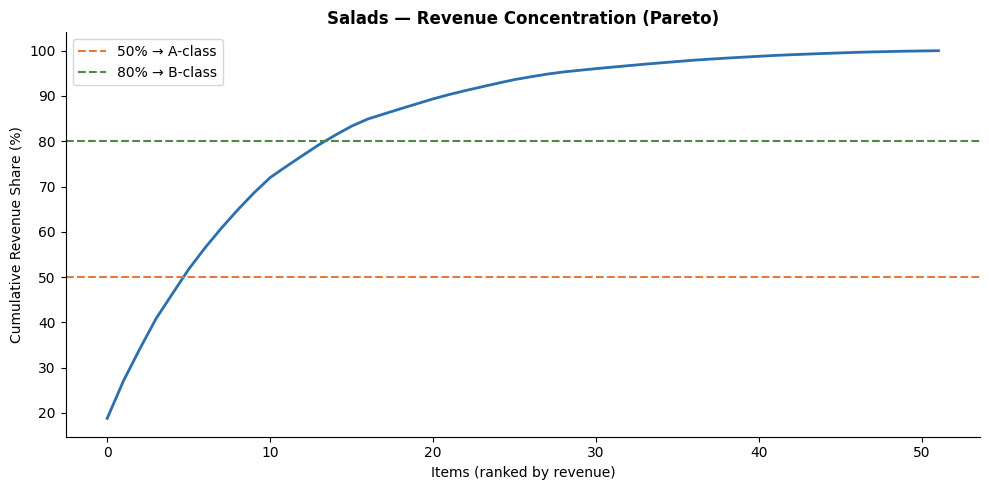

In [13]:
# ── ABC split summary ─────────────────────────────────────────────────────────
abc_summary = item_sales.groupby('ABC').agg(
    items=('name','count'),
    total_rev=('rev','sum'),
    avg_gp_pct=('gp_pct','mean')
).assign(rev_share=lambda d: d['total_rev']/total_salads_rev*100).round(2)
print("ABC classification:")
print(abc_summary.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2c6fad','#6dbf9e','#cccccc']
item_rev_sorted = item_sales.sort_values('rev', ascending=False).reset_index(drop=True)
ax.plot(range(len(item_rev_sorted)), item_rev_sorted['cum_share'],
        color='#2c6fad', linewidth=2)
ax.axhline(50, color='#e07b39', linestyle='--', label='50% → A-class')
ax.axhline(80, color='#4a8c3f', linestyle='--', label='80% → B-class')
ax.set_xlabel('Items (ranked by revenue)')
ax.set_ylabel('Cumulative Revenue Share (%)')
ax.set_title('Salads — Revenue Concentration (Pareto)')
ax.legend()
plt.tight_layout()
plt.savefig(str(CHARTS_DIR / 'salads_pareto.png'), dpi=150, bbox_inches='tight')
plt.show()


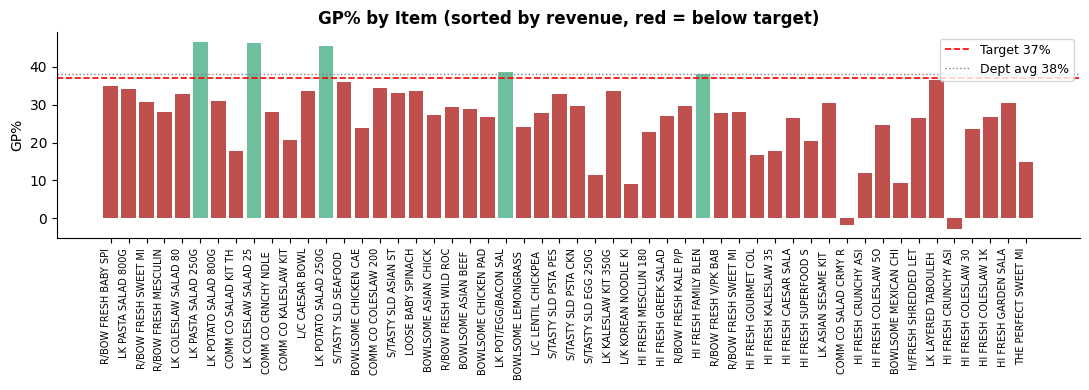


Items below 37% GP target: 47 of 52
                                   name    rev  gp_pct  presence_pct
          R/BOW FRESH BABY SPINACH 120G 3524.0    34.8          91.3
                    LK PASTA SALAD 800G 1557.3    34.0          76.1
           R/BOW FRESH SWEET MIX 120GMS 1318.2    30.6          93.5
        R/BOW FRESH MESCULIN MIX 120GMS 1257.1    27.9          90.2
                 LK COLESLAW SALAD 800G 1024.8    32.7          73.9
                   LK POTATO SALAD 800G  884.1    30.9          68.5
           COMM CO SALAD KIT THAI 285GM  812.2    17.8          60.9
          COMM CO CRNCHY NDLE KIT 450GM  704.9    28.0          64.1
             COMM CO KALESLAW KIT 400GM  638.0    20.6          60.9
                        L/C CAESAR BOWL  466.4    33.7          45.7
              S/TASTY SLD SEAFOOD 275GM  443.0    36.1          40.2
           BOWLSOME CHICKEN CAESAR 225G  397.1    23.8          30.4
                 COMM CO COLESLAW 200GM  371.3    34.4          62

In [14]:
# ── GP% distribution ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))

gp_sorted = item_sales.sort_values('rev', ascending=False)
colors_gp = ['#c0504d' if g < 37 else '#6dbf9e' for g in gp_sorted['gp_pct']]
bars = ax.bar(range(len(gp_sorted)), gp_sorted['gp_pct'], color=colors_gp)
ax.axhline(37.0, color='red', linestyle='--', linewidth=1.2, label='Target 37%')
ax.axhline(38.0, color='grey', linestyle=':', linewidth=1, label='Dept avg 38%')
ax.set_xticks(range(len(gp_sorted)))
ax.set_xticklabels(
    [n[:20] for n in gp_sorted['name']], rotation=90, ha='right', fontsize=7)
ax.set_ylabel('GP%')
ax.set_title('GP% by Item (sorted by revenue, red = below target)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(str(CHARTS_DIR / 'salads_gp_by_item.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nItems below 37% GP target: {(item_sales['gp_pct'] < 37).sum()} of {len(item_sales)}")
print(item_sales[item_sales['gp_pct'] < 37][['name','rev','gp_pct','presence_pct']].round(1).to_string(index=False))


## 5. Dump Waste Deep Dive

In [15]:
# ── Per-item dump summary ────────────────────────────────────────────────────
item_dump = (dump_salads.groupby('Description')
             .agg(dump_events=('Qty','count'),
                  dump_qty=('Qty','sum'),
                  dump_cost=('Total Cost ex','sum'),
                  reasons=('Reason', lambda x: ', '.join(sorted(x.unique()))))
             .reset_index()
             .sort_values('dump_cost', ascending=False))
item_dump['dump_cost_per_event'] = item_dump['dump_cost'] / item_dump['dump_events']

print(f"Unique salad items dumped: {len(item_dump)}")
print("\nPer-item dump detail:")
print(item_dump.round(2).to_string(index=False))


Unique salad items dumped: 33

Per-item dump detail:
                          Description  dump_events  dump_qty  dump_cost          reasons  dump_cost_per_event
     BOWLSOME ASIAN CHICKEN SLAW 290G            4      12.0      88.64          Expired                22.16
                 LK POTATO SALAD 800G            4      13.0      63.75 Damaged, Expired                15.94
BOWLSOME LEMONGRASS CHICK NOODLE 330G            4       8.0      59.44 Damaged, Expired                14.86
               LK COLESLAW SALAD 800G            5      12.0      59.16 Damaged, Expired                11.83
       S/TASTY SLD ASIAN STY RC 300GM            3      13.0      58.50 Damaged, Expired                19.50
BOWLSOME mexican chicken fajita 350gm            2       7.0      55.65 Damaged, Expired                27.82
      BOWLSOME CHICKEN Pad Thai 300gm            3       7.0      55.55 Damaged, Expired                18.52
         BOWLSOME CHICKEN CAESAR 225G            3       7.0      4

In [16]:
# ── Cross-reference dump with sales — dump cost as % of item sales revenue ────
item_dump['desc_norm'] = item_dump['Description'].apply(norm)
item_sales['desc_norm'] = item_sales['name'].apply(norm)

item_combined = pd.merge(
    item_sales[['name','desc_norm','rev','gp_pct','presence_pct','ABC']],
    item_dump[['desc_norm','dump_events','dump_qty','dump_cost']],
    on='desc_norm', how='left'
).fillna({'dump_events':0,'dump_qty':0,'dump_cost':0})

item_combined['dump_pct_rev'] = item_combined['dump_cost'] / item_combined['rev'] * 100
item_combined = item_combined.sort_values('dump_cost', ascending=False)

print("Items with dump activity (dump cost > 0):")
dumped = item_combined[item_combined['dump_cost'] > 0]
print(dumped[['name','rev','gp_pct','dump_events','dump_qty','dump_cost','dump_pct_rev']].round(2).to_string(index=False))


Items with dump activity (dump cost > 0):
                                 name     rev  gp_pct  dump_events  dump_qty  dump_cost  dump_pct_rev
     BOWLSOME ASIAN CHICKEN SLAW 290G  210.26   27.28          4.0      12.0      88.64         42.16
                 LK POTATO SALAD 800G  884.10   30.89          4.0      13.0      63.75          7.21
BOWLSOME LEMONGRASS CHICK NOODLE 330G  155.01   23.98          4.0       8.0      59.44         38.35
               LK COLESLAW SALAD 800G 1024.78   32.72          5.0      12.0      59.16          5.77
       S/TASTY SLD ASIAN STY RC 300GM  296.31   33.18          3.0      13.0      58.50         19.74
BOWLSOME MEXICAN CHICKEN FAJITA 350GM   25.14    9.27          2.0       7.0      55.65        221.36
      BOWLSOME CHICKEN PAD THAI 300GM  182.61   26.62          3.0       7.0      55.55         30.42
         BOWLSOME CHICKEN CAESAR 225G  397.11   23.81          3.0       7.0      49.93         12.57
        L/C LENTIL CHICKPEA TABBOULEH  1

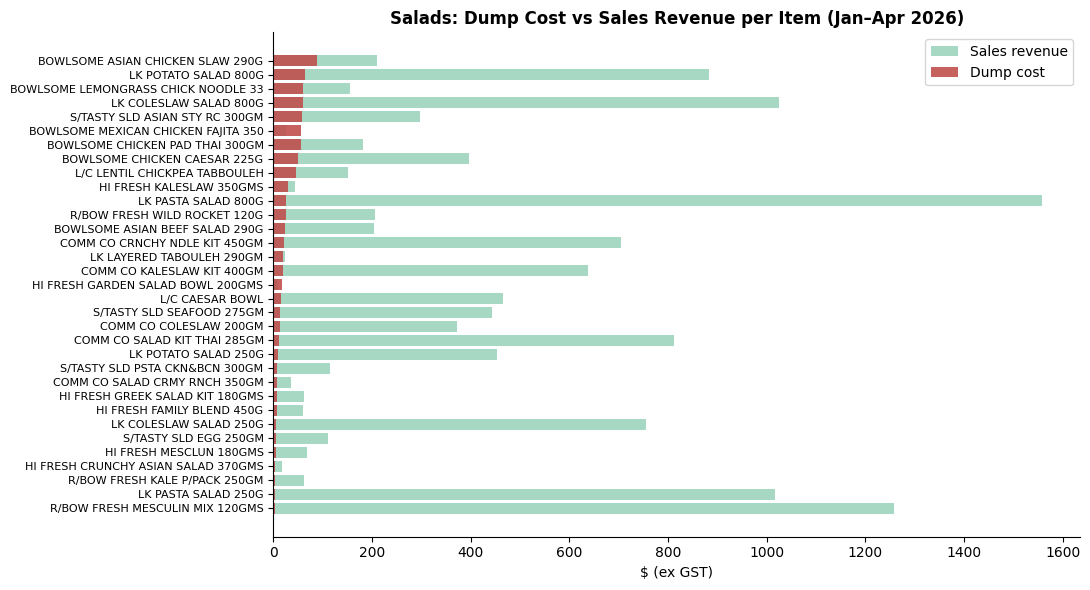

In [17]:
# ── Chart: dump cost vs sales by item ────────────────────────────────────────
dumped_sorted = dumped.sort_values('dump_cost', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
y = range(len(dumped_sorted))
ax.barh(y, dumped_sorted['rev'], color='#6dbf9e', alpha=0.6, label='Sales revenue')
ax.barh(y, dumped_sorted['dump_cost'], color='#c0504d', alpha=0.9, label='Dump cost')
ax.set_yticks(list(y))
ax.set_yticklabels([n[:35] for n in dumped_sorted['name']], fontsize=8)
ax.set_xlabel('$ (ex GST)')
ax.set_title('Salads: Dump Cost vs Sales Revenue per Item (Jan–Apr 2026)')
ax.legend()
plt.tight_layout()
plt.savefig(str(CHARTS_DIR / 'salads_dump_vs_sales.png'), dpi=150, bbox_inches='tight')
plt.show()


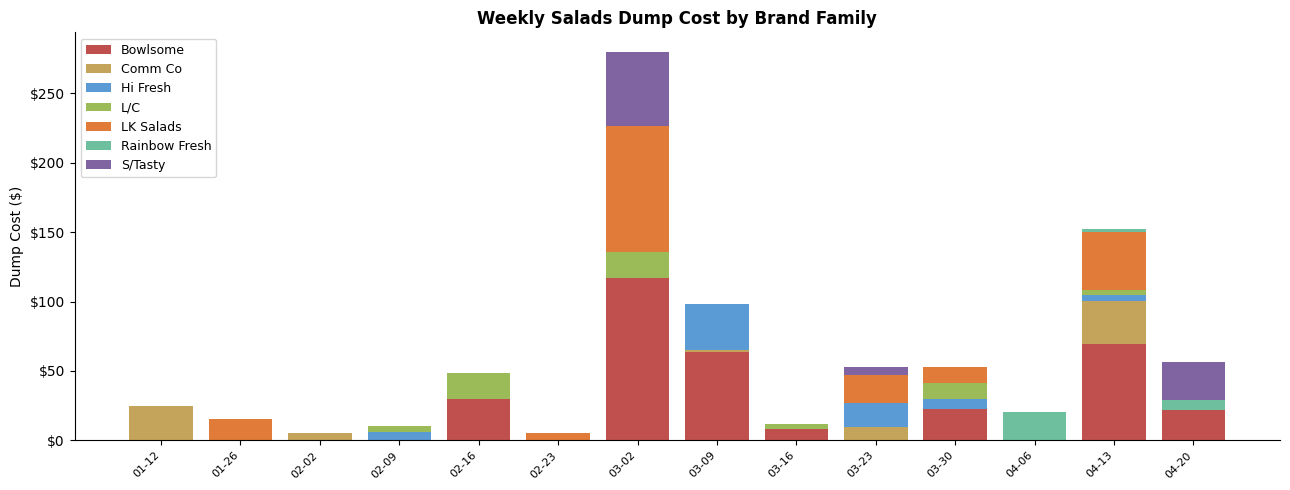


Dump cost by brand family:
               events   qty    cost
brand                              
Bowlsome           18  44.0  332.02
LK Salads          16  47.0  184.97
S/Tasty             6  19.0   85.68
Comm Co             9  23.0   71.20
Hi Fresh            6  19.0   69.26
L/C                 7  16.0   60.01
Rainbow Fresh       5  12.0   30.60


In [18]:
# ── Weekly dump trend by brand family ────────────────────────────────────────
dump_salads['brand'] = dump_salads['Description'].apply(lambda x:
    'Bowlsome' if 'BOWLSOME' in str(x).upper() else
    ('LK Salads' if str(x).upper().startswith('LK ') else
     ('Comm Co' if 'COMM CO' in str(x).upper() else
      ('Rainbow Fresh' if 'R/BOW' in str(x).upper() else
       ('Hi Fresh' if 'HI FRESH' in str(x).upper() else
        ('L/C' if str(x).upper().startswith('L/C ') else
         ('S/Tasty' if 'S/TASTY' in str(x).upper() else 'Other')))))))

brand_weekly = (dump_salads.groupby(['week','brand'])['Total Cost ex']
                .sum().reset_index())
brand_pivot = brand_weekly.pivot(index='week', columns='brand', values='Total Cost ex').fillna(0)

fig, ax = plt.subplots(figsize=(13, 5))
brand_colors = {
    'Bowlsome': '#c0504d', 'LK Salads': '#e07b39', 'Comm Co': '#c4a35a',
    'Rainbow Fresh': '#6dbf9e', 'Hi Fresh': '#5b9bd5', 'L/C': '#9bbb59',
    'S/Tasty': '#8064a2', 'Other': '#aaaaaa'
}
bottom = np.zeros(len(brand_pivot))
x = range(len(brand_pivot))
for brand in brand_pivot.columns:
    vals = brand_pivot[brand].values
    ax.bar(x, vals, bottom=bottom, label=brand,
           color=brand_colors.get(brand, '#999999'))
    bottom += vals
ax.set_xticks(list(x))
ax.set_xticklabels(brand_pivot.index.astype(str).str[5:10], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Dump Cost ($)')
ax.set_title('Weekly Salads Dump Cost by Brand Family')
ax.legend(fontsize=9, loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
plt.tight_layout()
plt.savefig(str(CHARTS_DIR / 'salads_dump_weekly_brand.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nDump cost by brand family:")
print(dump_salads.groupby('brand').agg(
    events=('Qty','count'), qty=('Qty','sum'), cost=('Total Cost ex','sum')
).sort_values('cost', ascending=False).round(2).to_string())


## 6. Markdown Deep Dive

In [19]:
# ── Markdown totals summary ───────────────────────────────────────────────────
print(f"Salads items marked down: {len(md_salads)}")
print(f"Total units marked down:  {md_salads['Qty'].sum():.0f}")
print(f"Potential sell value:      ${md_salads['Potential Sell'].sum():,.2f}")
print(f"Actual sell (discounted):  ${md_salads['Total Sell'].sum():,.2f}")
print(f"Revenue recovery rate:     {md_salads['Total Sell'].sum()/md_salads['Potential Sell'].sum()*100:.1f}%")
print(f"Total discount given:      ${md_salads['Discount Given'].sum():,.2f}")
print(f"Realised profit:           ${md_salads['Realised Profit'].sum():,.2f}")
print(f"Avg GP%:                   {md_salads['GP'].mean():.1f}%")


Salads items marked down: 37
Total units marked down:  347
Potential sell value:      $1,845.33
Actual sell (discounted):  $981.95
Revenue recovery rate:     53.2%
Total discount given:      $863.38
Realised profit:           $-204.27
Avg GP%:                   -21.8%


In [20]:
# ── Cross-reference markdown with sales ──────────────────────────────────────
item_md = md_salads.groupby('desc_norm').agg(
    md_qty=('Qty','sum'),
    md_potential=('Potential Sell','sum'),
    md_sell=('Total Sell','sum'),
    md_discount=('Discount Given','sum'),
    md_profit=('Realised Profit','sum'),
    md_gp_avg=('GP','mean')
).reset_index()

item_full = pd.merge(
    item_combined[['name','desc_norm','rev','gp_pct','presence_pct','ABC',
                   'dump_events','dump_qty','dump_cost','dump_pct_rev']],
    item_md,
    on='desc_norm', how='left'
).fillna({'md_qty':0,'md_potential':0,'md_sell':0,'md_discount':0,'md_profit':0,'md_gp_avg':np.nan})

item_full['md_discount_pct_rev'] = item_full['md_discount'] / item_full['rev'] * 100
item_full['md_loss'] = item_full['md_profit'].clip(upper=0).abs()
item_full['total_waste_cost'] = item_full['dump_cost'] + item_full['md_loss']
item_full['waste_pct_rev'] = item_full['total_waste_cost'] / item_full['rev'] * 100

print("Items with markdown activity:")
md_active = item_full[item_full['md_discount'] > 0].sort_values('md_discount', ascending=False)
print(md_active[['name','rev','gp_pct','md_qty','md_discount','md_gp_avg','md_discount_pct_rev']].round(1).to_string(index=False))


Items with markdown activity:
                                   name    rev  gp_pct  md_qty  md_discount  md_gp_avg  md_discount_pct_rev
        R/BOW FRESH MESCULIN MIX 120GMS 1257.1    27.9    81.0        165.4      -24.7                 13.2
           R/BOW FRESH SWEET MIX 120GMS 1318.2    30.6    52.0        102.4      -18.8                  7.8
             COMM CO KALESLAW KIT 400GM  638.0    20.6    24.0         77.0      -41.2                 12.1
           COMM CO SALAD KIT THAI 285GM  812.2    17.8    21.0         74.8      -53.4                  9.2
                   LK POTATO SALAD 800G  884.1    30.9    18.0         64.9      -13.7                  7.3
                 LK COLESLAW SALAD 800G 1024.8    32.7    13.0         46.1      -10.4                  4.5
                    LK PASTA SALAD 800G 1557.3    34.0    12.0         39.8       -9.1                  2.6
          R/BOW FRESH BABY SPINACH 120G 3524.0    34.8    25.0         37.5       -0.4                  1.

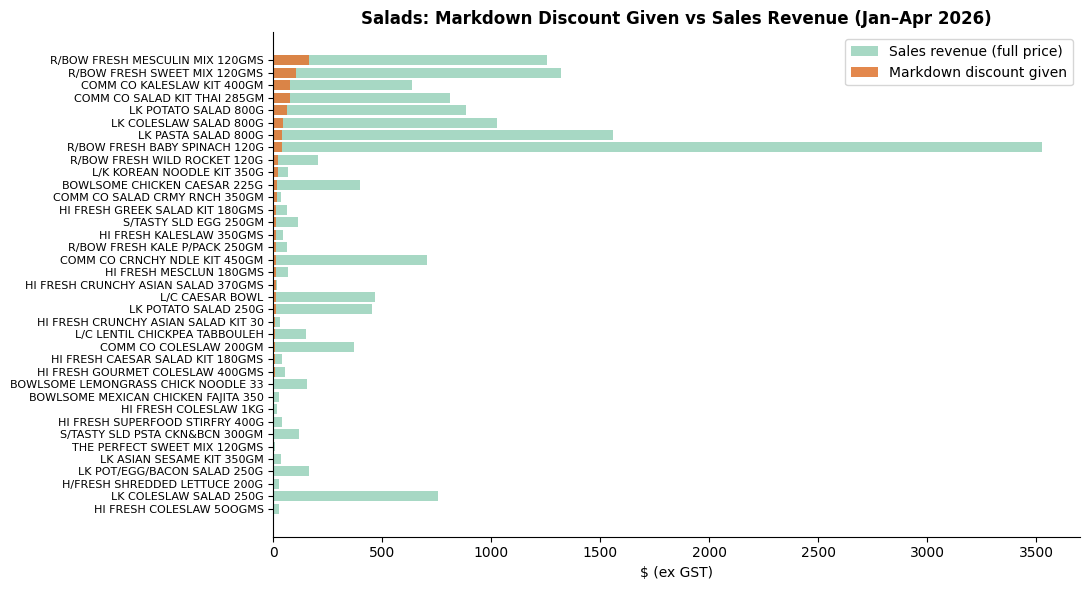

In [21]:
# ── Chart: discount given vs sales revenue by item ───────────────────────────
md_sorted = md_active.sort_values('md_discount', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
y = range(len(md_sorted))
ax.barh(y, md_sorted['rev'], color='#6dbf9e', alpha=0.6, label='Sales revenue (full price)')
ax.barh(y, md_sorted['md_discount'], color='#e07b39', alpha=0.9, label='Markdown discount given')
ax.set_yticks(list(y))
ax.set_yticklabels([n[:35] for n in md_sorted['name']], fontsize=8)
ax.set_xlabel('$ (ex GST)')
ax.set_title('Salads: Markdown Discount Given vs Sales Revenue (Jan–Apr 2026)')
ax.legend()
plt.tight_layout()
plt.savefig(str(CHARTS_DIR / 'salads_markdown_vs_sales.png'), dpi=150, bbox_inches='tight')
plt.show()


In [22]:
# ── Items where markdown discount > 10% of their own sales revenue ──────────
flagged_md = item_full[item_full['md_discount_pct_rev'] > 10].sort_values('md_discount_pct_rev', ascending=False)
print(f"Items where markdown discount > 10% of sales revenue: {len(flagged_md)}")
print(flagged_md[['name','rev','md_discount','md_discount_pct_rev','md_gp_avg','gp_pct']].round(1).to_string(index=False))


Items where markdown discount > 10% of sales revenue: 17
                                   name    rev  md_discount  md_discount_pct_rev  md_gp_avg  gp_pct
    HI FRESH CRUNCHY ASIAN SALAD 370GMS   17.5         12.0                 68.4      -44.0    -2.9
          COMM CO SALAD CRMY RNCH 350GM   36.0         18.0                 49.9      -69.3    -1.7
           THE PERFECT SWEET MIX 120GMS    9.2          3.9                 42.7      -48.5    15.0
                  HI FRESH COLESLAW 1KG   15.0          5.0                 33.3      -10.0    26.6
               HI FRESH KALESLAW 350GMS   43.4         12.9                 29.7      -51.2    17.8
             L/K KOREAN NOODLE KIT 350G   69.2         20.1                 29.1      -43.6     9.0
HI FRESH CRUNCHY ASIAN SALAD KIT 300GMS   29.4          7.1                 24.1      -51.0    11.9
        HI FRESH GREEK SALAD KIT 180GMS   62.7         13.5                 21.5        9.2    27.1
  BOWLSOME MEXICAN CHICKEN FAJITA 350GM   2

## 7. Combined Waste Picture per Item

In [23]:
# ── Summary table ────────────────────────────────────────────────────────────
waste_view = item_full[item_full['total_waste_cost'] > 0].sort_values('total_waste_cost', ascending=False).copy()

print(f"Items with any waste (dump or markdown loss): {len(waste_view)}")
print("\nCombined waste table:")
print(waste_view[['name','rev','gp_pct','dump_cost','md_loss','total_waste_cost','waste_pct_rev','ABC']].round(2).to_string(index=False))


Items with any waste (dump or markdown loss): 42

Combined waste table:
                                   name     rev  gp_pct  dump_cost  md_loss  total_waste_cost  waste_pct_rev ABC
       BOWLSOME ASIAN CHICKEN SLAW 290G  210.26   27.28      88.64     0.00             88.64          42.16   C
                   LK POTATO SALAD 800G  884.10   30.89      63.75    10.84             74.59           8.44   B
                 LK COLESLAW SALAD 800G 1024.78   32.72      59.16     6.00             65.16           6.36   A
  BOWLSOME LEMONGRASS CHICK NOODLE 330G  155.01   23.98      59.44     2.21             61.65          39.77   C
         S/TASTY SLD ASIAN STY RC 300GM  296.31   33.18      58.50     0.00             58.50          19.74   C
  BOWLSOME MEXICAN CHICKEN FAJITA 350GM   25.14    9.27      55.65     2.71             58.36         232.14   C
           BOWLSOME CHICKEN CAESAR 225G  397.11   23.81      49.93     7.57             57.50          14.48   C
        BOWLSOME CHICKEN

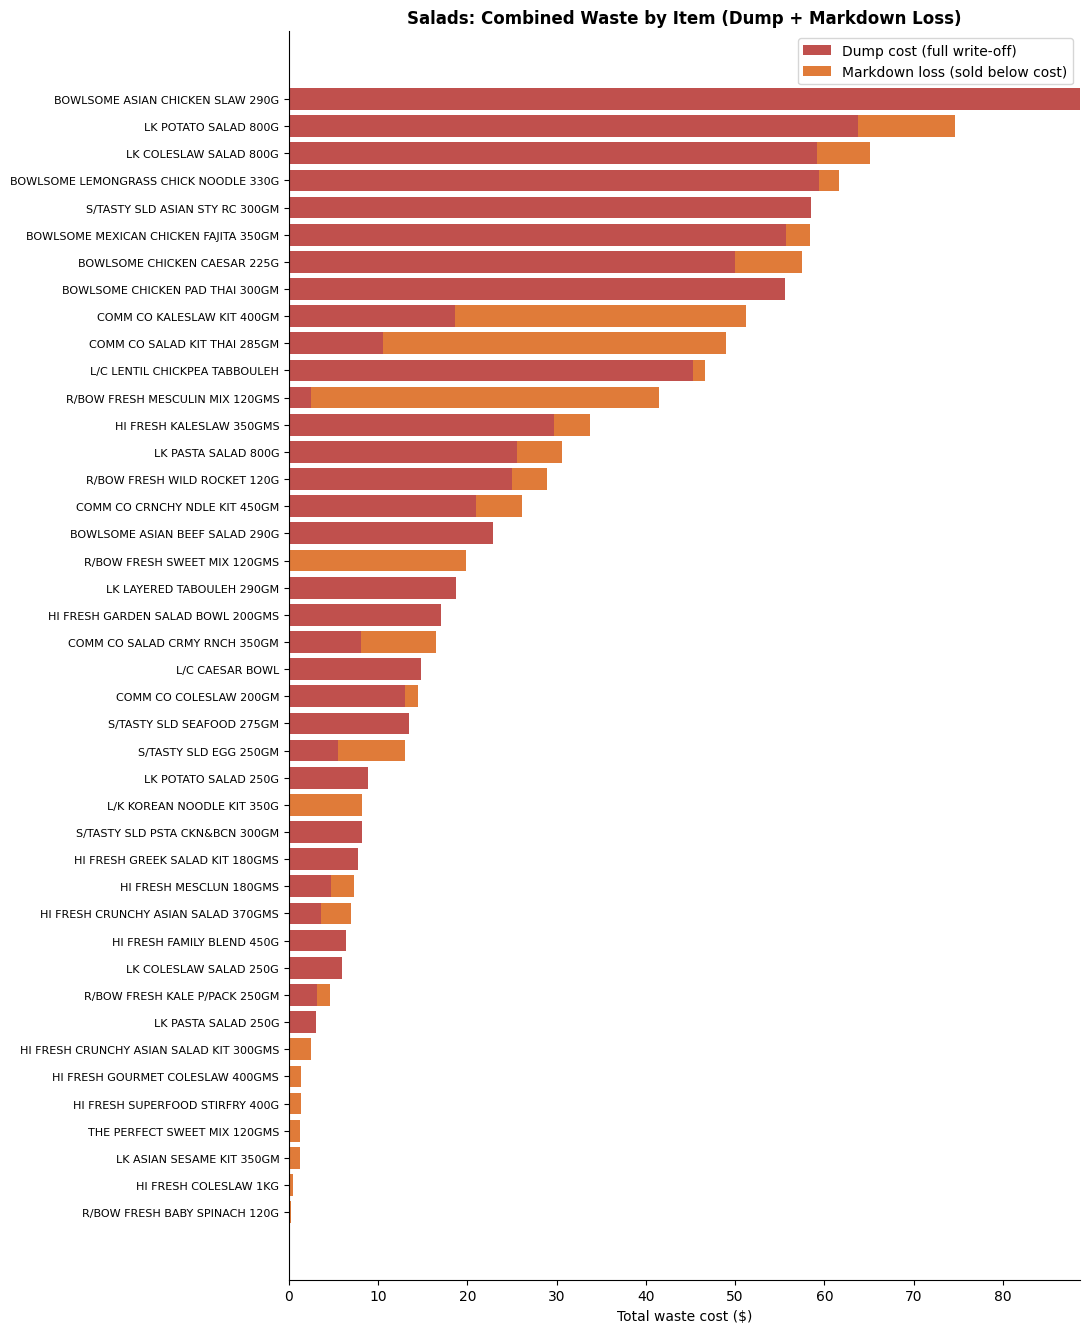

In [24]:
# ── Chart: total waste decomposed into dump + markdown loss ──────────────────
wv = waste_view.sort_values('total_waste_cost', ascending=True)
y  = range(len(wv))

fig, ax = plt.subplots(figsize=(11, max(6, len(wv)*0.32)))
ax.barh(y, wv['dump_cost'],  color='#c0504d', label='Dump cost (full write-off)')
ax.barh(y, wv['md_loss'],    left=wv['dump_cost'], color='#e07b39', label='Markdown loss (sold below cost)')
ax.set_yticks(list(y))
ax.set_yticklabels([n[:40] for n in wv['name']], fontsize=8)
ax.set_xlabel('Total waste cost ($)')
ax.set_title('Salads: Combined Waste by Item (Dump + Markdown Loss)')
ax.legend()
plt.tight_layout()
plt.savefig(str(CHARTS_DIR / 'salads_combined_waste.png'), dpi=150, bbox_inches='tight')
plt.show()


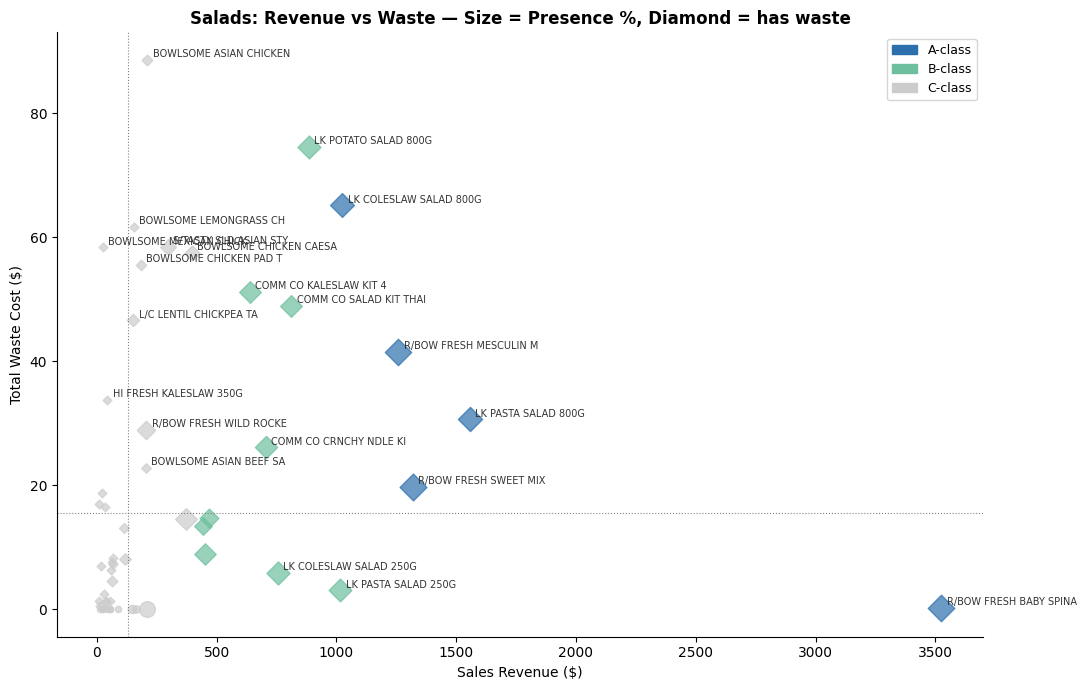

In [25]:
# ── Scatter: sales revenue vs waste cost — quadrant view ─────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
for _, row in item_full.iterrows():
    color = {'A':'#2c6fad','B':'#6dbf9e','C':'#cccccc'}.get(str(row['ABC']),'#cccccc')
    marker = 'D' if row['total_waste_cost'] > 0 else 'o'
    ax.scatter(row['rev'], row['total_waste_cost'], color=color,
               s=max(20, row['presence_pct']*2), alpha=0.7, marker=marker)
    if row['total_waste_cost'] > 20 or row['rev'] > 500:
        ax.annotate(row['name'][:22], (row['rev'], row['total_waste_cost']),
                    textcoords='offset points', xytext=(4, 2), fontsize=7, color='#333333')

# Quadrant lines
rev_median  = item_full['rev'].median()
waste_median= item_full[item_full['total_waste_cost']>0]['total_waste_cost'].median()
ax.axvline(rev_median,   color='grey', linestyle=':', linewidth=0.8)
ax.axhline(waste_median, color='grey', linestyle=':', linewidth=0.8)

# Legend
patches = [mpatches.Patch(color='#2c6fad', label='A-class'),
           mpatches.Patch(color='#6dbf9e', label='B-class'),
           mpatches.Patch(color='#cccccc', label='C-class')]
ax.legend(handles=patches, fontsize=9)
ax.set_xlabel('Sales Revenue ($)')
ax.set_ylabel('Total Waste Cost ($)')
ax.set_title('Salads: Revenue vs Waste — Size = Presence %, Diamond = has waste')
plt.tight_layout()
plt.savefig(str(CHARTS_DIR / 'salads_waste_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()


In [26]:
# ── Department-level waste rate ───────────────────────────────────────────────
total_dump_cost_salads = dump_salads['Total Cost ex'].sum()
total_md_loss_salads   = md_salads['Realised Profit'].clip(upper=0).abs().sum()
total_waste_salads     = total_dump_cost_salads + total_md_loss_salads

print("=" * 55)
print("  SALADS WASTE AS % OF REVENUE (Jan–Apr 2026)")
print("=" * 55)
print(f"  Total Salads revenue  : ${total_rev:>9,.2f}")
print(f"  Dump write-off cost   : ${total_dump_cost_salads:>9,.2f}  ({total_dump_cost_salads/total_rev*100:.1f}%)")
print(f"  Markdown loss         : ${total_md_loss_salads:>9,.2f}  ({total_md_loss_salads/total_rev*100:.1f}%)")
print(f"  TOTAL WASTE COST      : ${total_waste_salads:>9,.2f}  ({total_waste_salads/total_rev*100:.1f}%)")
print(f"  Target: < 5.0%        : {'✓ OK' if total_waste_salads/total_rev*100 < 5 else '✗ OVER'}")
print("=" * 55)
print(f"\n  Dump cost / week avg  : ${total_dump_cost_salads/PERIOD_WEEKS:>9,.2f}")
print(f"  Annualised dump run   : ${total_dump_cost_salads/PERIOD_WEEKS*52:>9,.2f}  (projected)")


  SALADS WASTE AS % OF REVENUE (Jan–Apr 2026)
  Total Salads revenue  : $18,744.51
  Dump write-off cost   : $   833.74  (4.4%)
  Markdown loss         : $   219.99  (1.2%)
  TOTAL WASTE COST      : $ 1,053.74  (5.6%)
  Target: < 5.0%        : ✗ OVER

  Dump cost / week avg  : $    49.04
  Annualised dump run   : $ 2,550.27  (projected)


## 8. Recommendations

### Salads performance summary (Jan–Apr 2026)
- 52 items · $18,745 revenue · **32.1% GP** (vs 38% department average — worst sub-dept by margin)
- Revenue/week: $1,103 · Revenue/day: $204
- **Total waste cost: $1,054 (5.6% of revenue)** — marginally over the 5% target
- Dump: $834 (4.4%) · Markdown loss: $220 (1.2%)
- Dump runs at **$49/week average** — annualised projection: ~$2,550/year in write-offs alone
- **14 of 17 weeks** had dump activity. This is not seasonal — it is structural over-ordering.

---

### Tier 1 — Delist immediately (negative or near-zero GP, chronic waste, minimal sales)

| Item | Rev | GP% | Waste cost | Waste % of rev |
|---|---|---|---|---|
| **Comm Co Salad Crmy Rnch 350GM** | $36 | **–1.7%** | $16 | 46% |
| **Bowlsome Mexican Chicken Fajita** | $25 | 9.3% | $58 | **232%** |
| **Hi Fresh Crunchy Asian Salad 370g** | $18 | –2.9% | $7 | 39% |
| **L/K Korean Noodle Kit 350g** | $69 | 9.0% | — | — |
| **S/Tasty Sld Egg 250GM** | $112 | 11.3% | $13 | 12% |
| **Hi Fresh Kaleslaw 350GMS** | $43 | 17.8% | $34 | **78%** |

These items cost more to buy and waste than they return in revenue. Remove from range immediately.

---

### Tier 2 — Order cuts of 30–40% (present in both dump and markdown, high waste rate)

| Item | Rev | GP% | Dump cost | MD discount | Total waste | Waste % |
|---|---|---|---|---|---|---|
| **Bowlsome Lemongrass Chick Noodle** | $155 | 24.0% | $59 | $5 | $62 | **40%** |
| **Bowlsome Chicken Caesar** | $397 | 23.8% | $50 | $18 | $58 | 14% |
| **LK Potato Salad 800g** | $884 | 30.9% | $64 | $65 | $75 | 8% |
| **L/C Lentil Chickpea Tabbouleh** | $152 | 27.9% | $45 | $7 | $47 | **31%** |
| **LK Coleslaw Salad 800g** | $1,025 | 32.7% | $59 | $46 | $65 | 6% |

For the Bowlsome range overall: 18 dump events, 44 units, $332 written off across 6 SKUs — the highest dump cost of any brand. Consider delisting all 6 SKUs or moving to order-to-need only (no standing order).

---

### Tier 3 — Reprice to 40% GP target (below-target GP but acceptable sales volume)

| Item | Rev | Current GP% | Gap to 40% target |
|---|---|---|---|
| **Comm Co Salad Kit Thai 285GM** | $812 | 17.8% | +22pp — significant reprice needed |
| **Comm Co Kaleslaw Kit 400GM** | $638 | 20.6% | +19pp |
| **Comm Co Crnchy Ndle Kit 450GM** | $705 | 28.0% | +12pp |
| **R/BOW Fresh Mesculin Mix 120g** | $1,257 | 27.9% | +12pp — highest-revenue item below target |
| **R/BOW Fresh Sweet Mix 120g** | $1,318 | 30.6% | +9pp |

---

### Expected financial impact (annualised)

| Action | Estimated saving |
|---|---|
| Delist Tier 1 (6 SKUs) | ~$400–500 dump/markdown cost removed |
| Cut Bowlsome range orders 40% | ~$800/yr dump reduction (largest dump contributor) |
| Cut Tier 2 orders 30–40% | ~$600/yr dump reduction |
| Reprice Tier 3 to 40% GP | ~$3,000–4,000/yr GP improvement on $14K revenue base |
| **Total estimated benefit** | **~$5,000–6,000/yr GP+waste improvement** |

The sub-department GP% would move from **32.1% toward 35–37%**, and weekly dump cost from $49/week toward **<$20/week**.


In [27]:
# ── Items in BOTH dump and markdown — highest-priority waste targets ───────────
in_both = item_full[(item_full['dump_cost'] > 0) & (item_full['md_discount'] > 0)].sort_values('total_waste_cost', ascending=False)
print(f"Items appearing in BOTH dump and markdown ({len(in_both)}):")
print("These carry inventory risk on two fronts — over-ordered AND forced to discount.")
print()
print(in_both[['name','ABC','rev','gp_pct','dump_cost','md_discount','total_waste_cost','waste_pct_rev']].round(2).to_string(index=False))

print(f"\nTotal waste cost for these {len(in_both)} items: ${in_both['total_waste_cost'].sum():,.2f}")
print(f"Their combined sales revenue:                   ${in_both['rev'].sum():,.2f}")
print(f"Waste as % of their own revenue:                {in_both['total_waste_cost'].sum()/in_both['rev'].sum()*100:.1f}%")


Items appearing in BOTH dump and markdown (24):
These carry inventory risk on two fronts — over-ordered AND forced to discount.

                                 name ABC     rev  gp_pct  dump_cost  md_discount  total_waste_cost  waste_pct_rev
                 LK POTATO SALAD 800G   B  884.10   30.89      63.75        64.90             74.59           8.44
               LK COLESLAW SALAD 800G   A 1024.78   32.72      59.16        46.12             65.16           6.36
BOWLSOME LEMONGRASS CHICK NOODLE 330G   C  155.01   23.98      59.44         5.27             61.65          39.77
BOWLSOME MEXICAN CHICKEN FAJITA 350GM   C   25.14    9.27      55.65         5.25             58.36         232.14
         BOWLSOME CHICKEN CAESAR 225G   C  397.11   23.81      49.93        18.25             57.50          14.48
           COMM CO KALESLAW KIT 400GM   B  638.04   20.56      18.60        76.96             51.16           8.02
         COMM CO SALAD KIT THAI 285GM   B  812.20   17.81      10.